In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

In [2]:
from src.research import AssetsResearch

from src.portfolio import Portfolio
from src.risk import PortfolioVolatilityAnalysis

In [3]:
ticket = "AMZO"
start = "2025-04-14"
end = "2026-04-12"

Asset = AssetsResearch(tickers=[ticket], start=start, end=end)

In [320]:
Asset._reset_cache()

In [321]:
prices = Asset.get_prices()
prices.tail()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Ticker,MELI
Date,
2026-03-25,1639.469971
2026-03-26,1630.989990
2026-03-27,1599.520020
2026-03-30,1619.199951
2026-03-31,1729.020020


In [322]:
len(prices)

751

In [323]:
# 2. Rendimientos logarítmicos
r = np.log(prices).diff().dropna() * 100# en %

In [283]:
# r: serie de rendimientos en %
split = int(len(prices) - 90)
train = r.iloc[:split]
test = r.iloc[split:]

pred_var = []
real_var = []

rolling_data = train.copy()

In [284]:
# 3. Modelo de media
arma = ARIMA(train, order=(2,0,3)).fit()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conve

In [285]:
arma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   MELI   No. Observations:                  473
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1077.644
Date:                Wed, 01 Apr 2026   AIC                           2169.287
Time:                        19:34:33   BIC                           2198.401
Sample:                             0   HQIC                          2180.738
                                - 473                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0681      0.116      0.586      0.558      -0.160       0.296
ar.L1          0.7734      0.023     33.504      0.000       0.728       0.819
ar.L2         -0.9646      0.022    -43.276      0.000      -1.008      -0.921
ma.L1         -0.8206      0.046    -18.017      0.000      -0.910      -0.731
ma.L2          0.9967      0.042     24.005      0.000       0.915       1.078
ma.L3         -0.0112      0.041     -0.271      0.787      -0.092       0.070
sigma2         5.5410      0.200     27.674      0.000       5.149       5.933
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):              1314.42
Prob(Q):                              0.75   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                            -1.00
Prob(H) (two-sided):                  0.77   Kurtosis:                        10.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Date'>

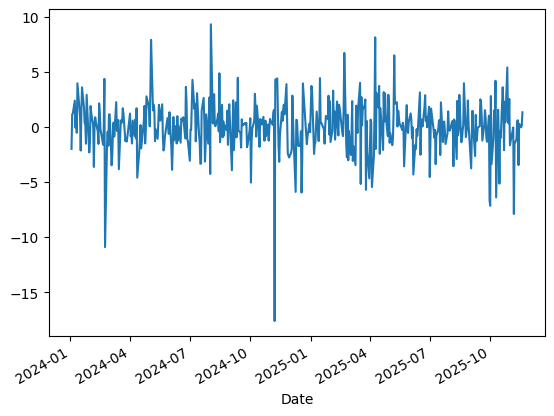

In [286]:
# 3. Modelo de media
residuos = arma.resid.dropna()

residuos.plot()

In [287]:
# 4. Prueba ARCH-LM
lm_stat, lm_pvalue, _, _ = het_arch(residuos, nlags=20)


In [288]:
lm_pvalue

np.float64(0.999996204418935)

In [300]:
modelo = arch_model(residuos, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
fit = modelo.fit(disp="off")

In [301]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Zero Mean - GARCH Model Results                        
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -1074.01
Distribution:                  Normal   AIC:                           2154.01
Method:            Maximum Likelihood   BIC:                           2166.49
                                        No. Observations:                  473
Date:                Wed, Apr 01 2026   Df Residuals:                      473
Time:                        19:43:41   Df Model:                            0
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          4.8731      0.973      5.009  5.474e-07 [  2.966,  6.780]
alpha[1]       0.1455      0.156      0.935      0.350 [ -0.159,  0.450]
beta[1]        0.0000      0.103      0.000      1.000 [ -0.201,  0.201]
========================================================================

Covariance estimator: robust
"""

In [ ]:
for i in range(len(test)):
    model = arch_model(
        rolling_data, 
        mean="Zero", 
        vol="EGARCH", 
        p=2, 
        q=1,
        o=1, 
        dist="skewt"
        )
    
    fit = model.fit(disp="off")
    
    fcast = fit.forecast(horizon=1)
    var_1step = fcast.variance.iloc[-1, 0]   # h.1
    
    pred_var.append(var_1step)
    real_var.append(test.iloc[i]**2)
    
    rolling_data = pd.concat([rolling_data, test.iloc[i:i+1]])

In [292]:
# 6. Parámetros
omega = fit.params["omega"]
alpha = fit.params["alpha[1]"]
beta  = fit.params["beta[1]"]

# 7. Varianza y volatilidad de largo plazo
if alpha + beta < 1:
    var_lp = omega / (1 - alpha - beta)
    vol_lp = np.sqrt(var_lp)
    print("Varianza de largo plazo:", var_lp)
    print("Volatilidad de largo plazo:", vol_lp * np.sqrt(252))
else:
    print(alpha + beta)

1.1210389970477694


In [293]:
pred_var = np.array(pred_var)
real_var = np.array(real_var)

mse = np.mean((pred_var - real_var)**2)
mae = np.mean(np.abs(pred_var - real_var))
qlike = np.mean(np.log(pred_var) + real_var / pred_var)

print("MSE:", mse)
print("MAE:", mae)
print("QLIKE:", qlike)

MSE: 223.52076850845296
MAE: 8.170413115352774
QLIKE: 3.029914717989966


<Axes: >

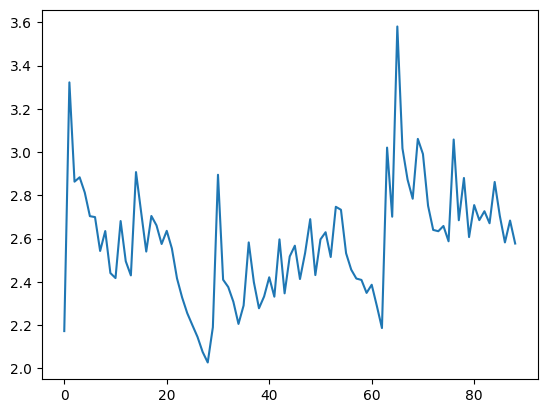

In [298]:
pd.Series(np.sqrt(pred_var)).plot() 

In [297]:
real_var.T[0]

array([7.97250286e+01, 7.30053011e+00, 8.32639556e+00, 5.14317167e+00,
       1.12486160e+00, 3.51122260e+00, 1.22209438e-01, 6.03814137e+00,
       3.42618313e-02, 8.58271463e-01, 1.20983095e+01, 1.11545637e+00,
       4.44703585e-01, 2.63235570e+01, 6.05133138e+00, 3.77402150e-02,
       6.08770193e+00, 2.87028991e+00, 8.20794649e-01, 6.16606201e+00,
       2.80029438e+00, 3.93751334e-02, 5.06899465e-03, 2.47322719e-02,
       1.40350113e-01, 2.12170701e-01, 8.57769440e-02, 1.07661119e-01,
       4.13795259e+00, 7.21071026e+01, 3.14112497e+00, 1.26184199e+00,
       6.26832691e-01, 4.06966586e-03, 1.73552393e+00, 1.30678574e+01,
       1.84787854e+00, 2.17810329e-02, 1.30499655e+00, 3.82540444e+00,
       1.25788453e+00, 2.07823175e+01, 5.88568098e-01, 1.19983933e+01,
       1.33630142e+01, 1.33862570e+00, 5.05979395e+00, 1.03874285e+01,
       7.04669557e-04, 4.96589604e+00, 5.15049033e+00, 7.77413528e-01,
       1.04123584e+01, 1.06772045e+01, 2.55833653e-01, 1.24718062e-01,
      

<Axes: >

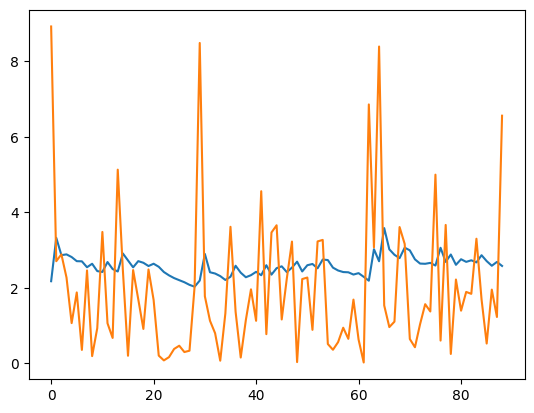

In [296]:
pd.Series(np.sqrt(pred_var)).plot()
pd.Series(np.sqrt(real_var.T[0])).plot()

In [ ]:
real_var

## Varianza acumulada

In [318]:
r.std() * np.sqrt(252)

Ticker
MELI    39.228561
dtype: float64

In [315]:
R = Asset.get_returns() * 100 
R.std() * np.sqrt(252)

Ticker
MELI    39.074244
dtype: float64

In [ ]:
# r: serie de rendimientos en %
split = int(len(r) - 90)
train = r.iloc[:split]
test = r.iloc[split:]

pred_var = []
real_var = []

rolling_data = train.copy()

In [332]:
arma = ARIMA(train, order=(2,0,3)).fit()

arma.summary()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conve

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   MELI   No. Observations:                  660
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1504.332
Date:                Wed, 01 Apr 2026   AIC                           3022.664
Time:                        19:53:34   BIC                           3054.110
Sample:                             0   HQIC                          3034.853
                                - 660                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0828      0.087      0.952      0.341      -0.088       0.253
ar.L1         -0.0707      0.012     -5.869      0.000      -0.094      -0.047
ar.L2         -0.9868      0.010    -97.265      0.000      -1.007      -0.967
ma.L1          0.0015      0.037      0.041      0.967      -0.071       0.074
ma.L2          0.9746      0.017     57.104      0.000       0.941       1.008
ma.L3         -0.1030      0.036     -2.825      0.005      -0.174      -0.032
sigma2         5.5567      0.194     28.703      0.000       5.177       5.936
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              1161.20
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                            -0.54
Prob(H) (two-sided):                  0.90   Kurtosis:                         9.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [336]:
residuos = arma.resid

lm_stat, lm_pvalue, _, _ = het_arch(residuos, nlags=90)

lm_pvalue


np.float64(0.9999996381299979)

In [ ]:
modelo = arch_model(residuos, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
fit = modelo.fit(disp="off")

In [ ]:
forecast = fit.forecast(horizon=50)
pred_path_var = forecast.variance.iloc[-1].values   # h.1 ... h.50

pred_50d_var = pred_path_var.sum()
pred_50d_vol = np.sqrt(pred_50d_var)

# rendimientos observados realmente después del punto de pronóstico
real_50d_returns = r_futuro.iloc[:50].values
real_50d_var = np.sum(real_50d_returns**2)
real_50d_vol = np.sqrt(real_50d_var)

print("Volatilidad pronosticada 50d:", pred_50d_vol)
print("Volatilidad realizada 50d:", real_50d_vol)

# EWMA

In [7]:
AMZO = Portfolio(prices=Asset.get_prices(), weights=[1], name="AMZO")

In [8]:
vol_model = PortfolioVolatilityAnalysis(portfolio=AMZO)

returns = AMZO.portfolio_returns()

realized_proxy = returns.pow(2)

candidate_lambdas = np.arange(0.8, 0.995,0.0001)

best_lambda = None

best_loss = float("inf")


for lambda_ in candidate_lambdas:
    ewma_var = vol_model.ewma_variance_series(
        decay=lambda_,
        annualize=False,
    )

    # Pronóstico para t usando info hasta t-1
    forecast = ewma_var.shift(1).dropna()
    target = realized_proxy.loc[forecast.index]

    loss = ((target - forecast) ** 2).mean()

    if loss < best_loss:
        best_loss = loss
        best_lambda = lambda_

print("Mejor lambda:", best_lambda)
print("Loss:", best_loss)

Mejor lambda: 0.9838999999999798
Loss: 1.3964553577067489e-05


In [9]:
ewma_vol = vol_model.ewma_volatility_series(decay=best_lambda)
latest_vol = vol_model.latest_ewma_volatility(decay=best_lambda)

print(ewma_vol.tail())
print("Ultima volatilidad EWMA:", latest_vol)

Date
2026-04-06    0.676719
2026-04-07    0.671500
2026-04-08    0.680238
2026-04-09    0.709884
2026-04-10    0.709538
Name: AMZO, dtype: float64
Ultima volatilidad EWMA: 0.709538328918353
